
**本 notebook 用于理解期权最基础的四种收益结构：

1. Long Call
2. Short Call
3. Long Put
4. Short Put

目标不是做复杂策略，而是通过图形理解期权和期货在线性/非线性风险结构上的区别。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# 01 Option Payoff


In [2]:
S = np.linspace(50, 150, 500)
K = 100
premium = 5

In [3]:
def long_call_profit(S, K, premium):
    return np.maximum(S - K, 0) - premium


def short_call_profit(S, K, premium):
    return -long_call_profit(S, K, premium)


def long_put_profit(S, K, premium):
    return np.maximum(K - S, 0) - premium


def short_put_profit(S, K, premium):
    return -long_put_profit(S, K, premium)

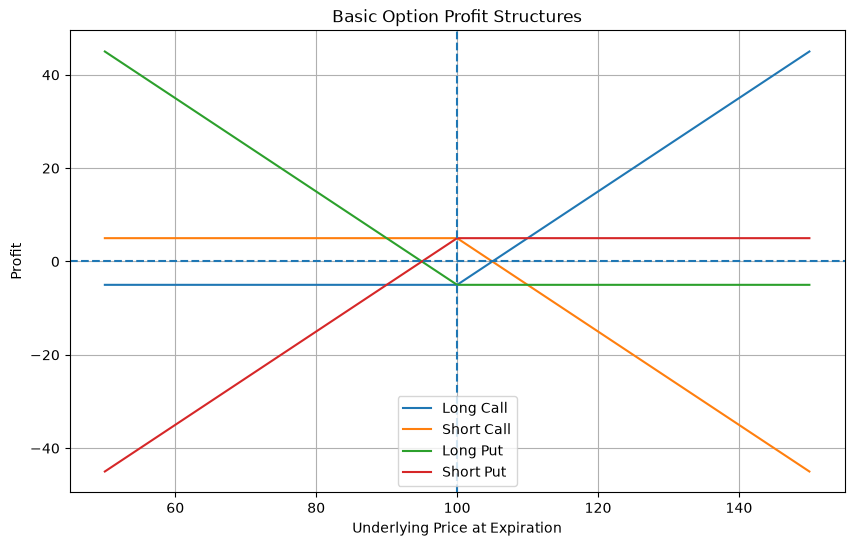

In [4]:
strategies = {
    "Long Call": long_call_profit(S, K, premium),
    "Short Call": short_call_profit(S, K, premium),
    "Long Put": long_put_profit(S, K, premium),
    "Short Put": short_put_profit(S, K, premium),
}

plt.figure(figsize=(10, 6))

for name, profit in strategies.items():
    plt.plot(S, profit, label=name)

plt.axhline(0, linestyle="--")
plt.axvline(K, linestyle="--")
plt.title("Basic Option Profit Structures")
plt.xlabel("Underlying Price at Expiration")
plt.ylabel("Profit")
plt.legend()
plt.grid(True)
plt.show()

## Summary

通过本 notebook，我初步理解了四种基础期权头寸的盈亏结构：

1. Long Call：亏损有限，向上收益理论上无限。
2. Short Call：收益有限，向上亏损理论上无限。
3. Long Put：亏损有限，标的下跌时获利。
4. Short Put：收益有限，标的下跌时风险较大。

期货是线性风险工具，而期权是非线性风险工具。期权的价值不仅在于判断方向，更在于设计风险结构、管理风险敞口和交易波动率。